# Shopper Spectrum: Customer Segmentation and Product Recommendations
## Step 1: Dataset Collection, Understanding, and Initial Diagnostics

### Project Overview
The objective of this project is to leverage transactional e-commerce data to:
1. **Segment Customers:** Group users based on Recency, Frequency, and Monetary (RFM) metrics via unsupervised clustering.
2. **Product Recommendations:** Build an item-based collaborative filtering engine to recommend similar products.

### Notebook Objective
In this step, we load the raw `online_retail.csv` dataset, inspect its schema, check for missing values, and flag baseline data anomalies (like negative prices or quantities) that require data cleaning.

In [89]:
import pandas as pd
import numpy as np

# Load the dataset locally
print("🔄 Loading dataset...")
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
print(f"✅ Success! Dataset loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.\n")

# 1. Structural Schema Info
print("--- 📊 Dataset Schema Overview ---")
df.info()

# 2. Missing Value Check
print("\n--- 🔍 Missing Values Analysis ---")
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percentages})
print(missing_df[missing_df['Missing Count'] > 0])

# 3. Duplicate Row Check
duplicates = df.duplicated().sum()
print("\n--- 👥 Duplicate Rows ---")
print(f"Total duplicate rows identified: {duplicates:,}")

# 4. Numerical Outliers & Negative Values
print("\n--- 🔢 Descriptive Statistics (Numeric Columns) ---")
print(df.describe())

🔄 Loading dataset...
✅ Success! Dataset loaded with 541,909 rows and 8 columns.

--- 📊 Dataset Schema Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

--- 🔍 Missing Values Analysis ---
             Missing Count  Percentage (%)
Description           1454        0.268311
CustomerID          135080       24.926694

--- 👥 Duplicate Rows ---
Total duplicate rows identified: 5,268

--- 🔢 Descriptive Statistics (Numeric Columns) ---
 

## Step 2: Data Preprocessing & Cleaning

### Cleaning Actions:
1. **Drop Missing IDs:** Eliminate rows where `CustomerID` is null.
2. **Remove Cancellations:** Exclude any transaction where `InvoiceNo` starts with the letter 'C'
3. **Filter Out Non-Positives:** Keep only transactions where `Quantity > 0` and `UnitPrice > 0`.
4. **Remove Duplicates:** Drop exact duplicate records.
5. **Format Datetime:** Convert `InvoiceDate` from string to a proper pandas `datetime` format.

In [90]:
print("🧹 Starting data cleaning process...\n")

# 1. Drop missing CustomerIDs
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Exclude cancelled invoices (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Keep only strictly positive quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 4. Remove exact duplicate records
df_clean = df_clean.drop_duplicates()

# 5. Convert InvoiceDate to datetime objects
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 6. Verify changes
print("--- 🎉 Post-Cleaning Diagnostics ---")
print(f"Original dataset rows: {len(df):,}")
print(f"Cleaned dataset rows:  {len(df_clean):,}")
print(f"Rows dropped:          {len(df) - len(df_clean):,}")
print(f"\nMinimum Quantity remaining: {df_clean['Quantity'].min()}")
print(f"Minimum UnitPrice remaining: {df_clean['UnitPrice'].min()}")
print(f"Missing CustomerIDs left:    {df_clean['CustomerID'].isnull().sum()}")

🧹 Starting data cleaning process...

--- 🎉 Post-Cleaning Diagnostics ---
Original dataset rows: 541,909
Cleaned dataset rows:  392,692
Rows dropped:          149,217

Minimum Quantity remaining: 1
Minimum UnitPrice remaining: 0.001
Missing CustomerIDs left:    0


## Step 3: Exploratory Data Analysis (EDA)

### Objectives:
1. **Top Countries:** Identify where the majority of transactions are originating.
2. **Top Products:** Track down the highest-selling products by total volume.
3. **Monetary Distribution:** Understand how much money customers spend per transaction.

📊 Generating Country Analysis...


C:\Users\rahul\AppData\Local\Temp\ipykernel_14812\3957317574.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')


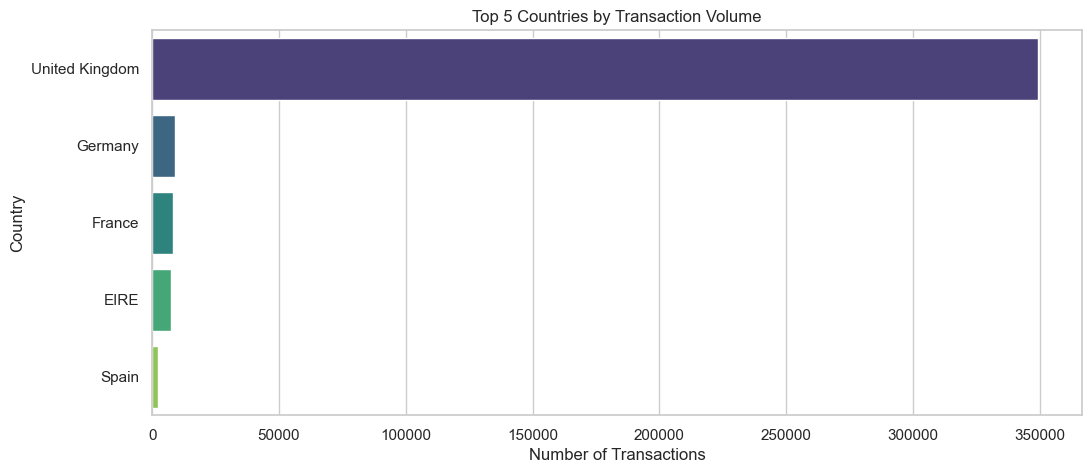


📊 Generating Product Analysis...


C:\Users\rahul\AppData\Local\Temp\ipykernel_14812\3957317574.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='rocket')


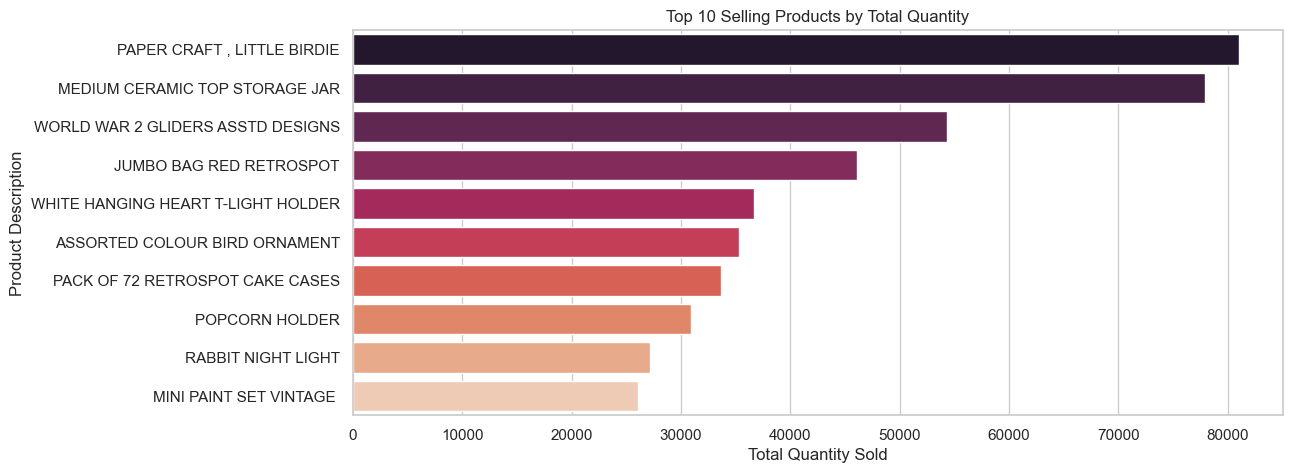


📊 Generating Monetary Distribution Analysis...


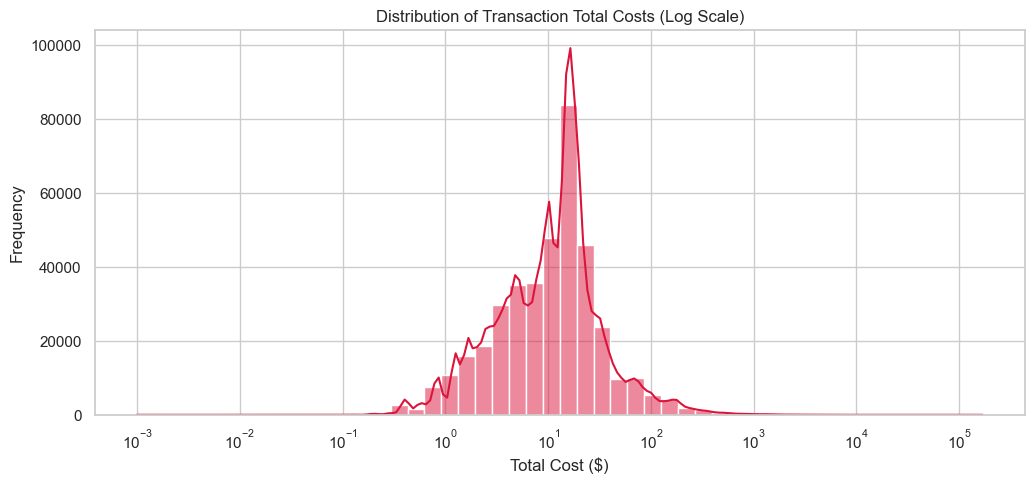

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# 1. Transaction Volume by Country (Top 5)
print("📊 Generating Country Analysis...")
plt.figure()
country_counts = df_clean['Country'].value_counts().head(5)
sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')
plt.title('Top 5 Countries by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()

# 2. Identify Top-Selling Products (Top 10)
print("\n📊 Generating Product Analysis...")
plt.figure()
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='rocket')
plt.title('Top 10 Selling Products by Total Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.show()

# 3. Create Total Cost column for Monetary Distribution
df_clean['TotalCost'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("\n📊 Generating Monetary Distribution Analysis...")
plt.figure()
# Fixed the typo here: closed the quote on 'crimson' and added the missing comma
sns.histplot(df_clean['TotalCost'], bins=50, kde=True, color='crimson', log_scale=True)
plt.title('Distribution of Transaction Total Costs (Log Scale)')
plt.xlabel('Total Cost ($)')
plt.ylabel('Frequency')
plt.show()

## Step 4: Clustering Methodology - RFM Feature Engineering

### Definition of RFM Metrics:
1. **Recency ($R$):** Days since the customer's last purchase relative to the dataset reference date.
2. **Frequency ($F$):** Total number of unique transactions per customer.
3. **Monetary ($M$):** Total dollar value spent by the customer.

After computing these features, we will apply standardization to avoid attributes with larger ranges dominating the distance computations.

In [92]:
from sklearn.preprocessing import StandardScaler

print("⚙️ Computing RFM metrics per customer...")

# 1. Establish the reference date as the maximum date in the dataset plus 1 day
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Group by CustomerID and calculate RFM metrics
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalCost': 'sum'                                      # Monetary
})

# Rename columns to match conventions
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalCost': 'Monetary'
}, inplace=True)

print(f"✅ Extracted RFM metrics for {rfm.shape[0]:,} unique customers.")

# 3. Scale the features for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("\n--- 📊 Sample RFM Calculated Metrics ---")
print(rfm.head())

print("\n--- 🔢 Sample Scaled RFM Metrics ---")
print(rfm_scaled_df.head())

⚙️ Computing RFM metrics per customer...
✅ Extracted RFM metrics for 4,338 unique customers.

--- 📊 Sample RFM Calculated Metrics ---
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40

--- 🔢 Sample Scaled RFM Metrics ---
             Recency  Frequency  Monetary
CustomerID                               
12346.0     2.334574  -0.425097  8.363010
12347.0    -0.905340   0.354417  0.251699
12348.0    -0.175360  -0.035340 -0.027988
12349.0    -0.735345  -0.425097 -0.032406
12350.0     2.174578  -0.425097 -0.190812


## Step 5: Hyperparameter Tuning & Unsupervised Clustering

### Objectives:
1. **Elbow Method:** Calculate the Within-Cluster Sum of Squares (WCSS / Inertia) across multiple cluster counts ($k \in [1, 10]$) to find where returns diminish.

2.**K-Means Execution:** Fit the optimal K-Means algorithm using our scaled matrix and extract group labels.

🏋️‍♂️ Training parallel K-Means iterations to calculate the Elbow Curve...


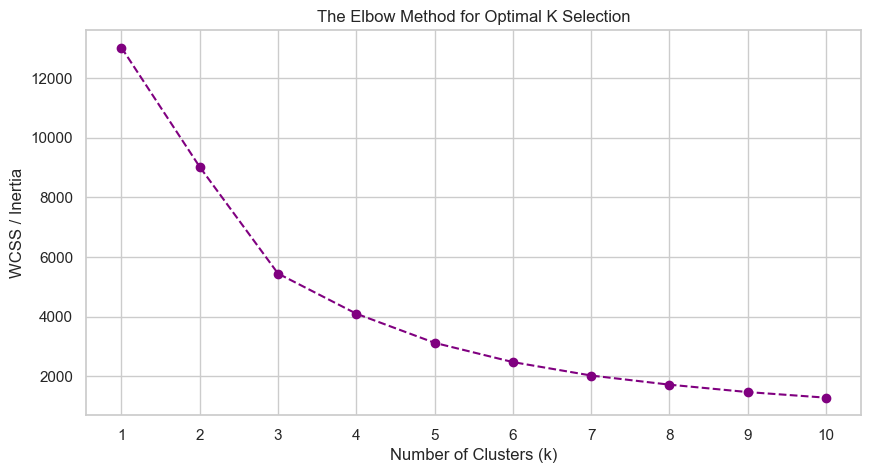


🎯 Fitting final K-Means model with k=4 clusters...

--- 📈 Customer Count Per Assigned Cluster ---
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [93]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("🏋️‍♂️ Training parallel K-Means iterations to calculate the Elbow Curve...")

# 1. Run KMeans for values from 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    # random_state ensures reproducibility
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# 2. Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='purple')
plt.title('The Elbow Method for Optimal K Selection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS / Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 3. Fit the chosen model (Standard industry sweet spot for RFM is k=4)
print("\n🎯 Fitting final K-Means model with k=4 clusters...")
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = final_kmeans.fit_predict(rfm_scaled)

print("\n--- 📈 Customer Count Per Assigned Cluster ---")
print(rfm['Cluster'].value_counts().sort_index())

## Step 6: Customer Cluster Profiles & Interpretation

### Objective:
Group the unscaled metrics by our new cluster assignments to compute group averages. We then map these profiles to our target business archetypes:
 **High-Value:** Regular, frequent, recent, and big spenders.
 **Regular:** Steady purchasers but not premium.
 **Occasional:** Rare, occasional purchases.
 **At-Risk:** Haven't purchased in a long time.

In [94]:
import pickle

print("📊 Profiling clusters to reveal behavioral patterns...")

# 1. Group by Cluster and calculate the mean values of raw RFM features
cluster_profiles = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max', 'count']
}).round(2)

print("\n--- 🔍 Cluster Profiling Statistics Table ---")
print(cluster_profiles)

# 2. Save the trained clustering model and the scaler for our future Streamlit application
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(final_kmeans, f)
    
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n💾 Success! Saved 'kmeans_model.pkl' and 'scaler.pkl' for use in the app deployment stage.")

📊 Profiling clusters to reveal behavioral patterns...

--- 🔍 Cluster Profiling Statistics Table ---
        Recency           Frequency            Monetary                       \
           mean  min  max      mean min  max       mean       min        max   
Cluster                                                                        
0         43.70    1  163      3.68   1   15    1353.63      6.20   21429.39   
1        248.08  143  374      1.55   1   12     478.85      3.75    9864.26   
2          7.38    1   39     82.54   2  209  127187.96  33053.19  280206.02   
3         15.50    1  372     22.33   1   93   12690.50   1296.44   77183.60   

               
        count  
Cluster        
0        3054  
1        1067  
2          13  
3         204  

💾 Success! Saved 'kmeans_model.pkl' and 'scaler.pkl' for use in the app deployment stage.


## Step 7: Labeling Clusters and 3D Behavior Visualization

### Mapping Summary:
* **Cluster 0** -> `Occasional Shopper`
* **Cluster 1** -> `At-Risk Customer`
* **Cluster 2** -> `High-Value Customer`
* **Cluster 3** -> `Regular Shopper`

We now append these meaningful labels back to our dataset and generate a 3D scatter plot of our Recency, Frequency, and Monetary scores to visually separate these customer segments.

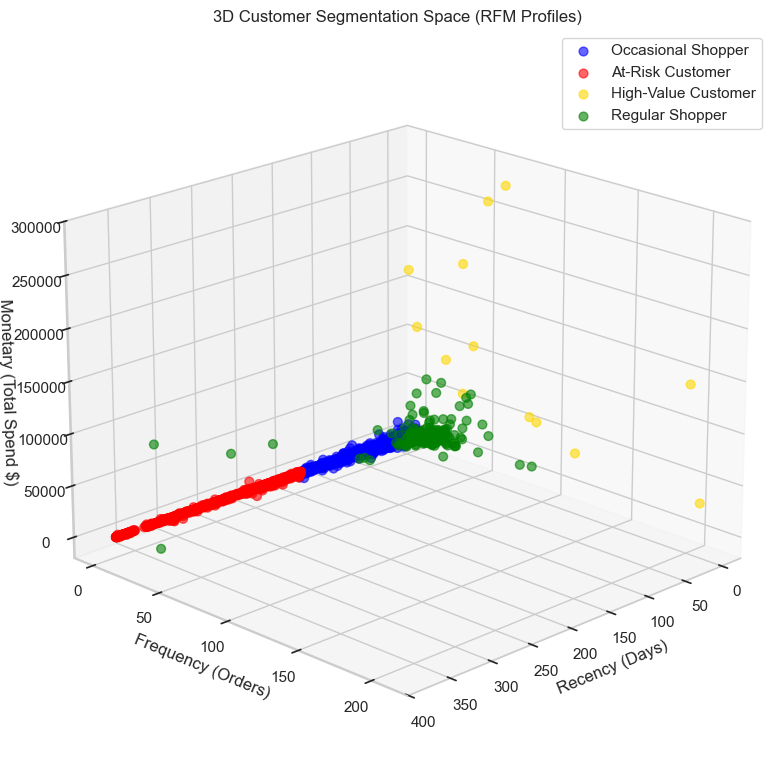

--- 📋 Sample Segmented Final Dataframe ---
            Recency  Frequency  Monetary             Segment
CustomerID                                                  
12346.0         326          1  77183.60     Regular Shopper
12347.0           2          7   4310.00  Occasional Shopper
12348.0          75          4   1797.24  Occasional Shopper
12349.0          19          1   1757.55  Occasional Shopper
12350.0         310          1    334.40    At-Risk Customer


In [95]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define the cluster mapping dictionary based on statistical analysis
cluster_map = {
    0: 'Occasional Shopper',
    1: 'At-Risk Customer',
    2: 'High-Value Customer',
    3: 'Regular Shopper'
}

# Apply the mapping labels
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

# 2. Setup a 3D Scatter Plot to visualize customer segmentation
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define distinct colors for our segments
colors = {'Occasional Shopper': 'blue', 'At-Risk Customer': 'red', 
          'High-Value Customer': 'gold', 'Regular Shopper': 'green'}

for segment, color in colors.items():
    segmented_data = rfm[rfm['Segment'] == segment]
    ax.scatter(segmented_data['Recency'], 
               segmented_data['Frequency'], 
               segmented_data['Monetary'], 
               c=color, 
               label=segment, 
               s=40, 
               alpha=0.6)

# Set labels (using log scale or trimming visual limits might be helpful due to outliers)
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Orders)')
ax.set_zlabel('Monetary (Total Spend $)')
ax.set_title('3D Customer Segmentation Space (RFM Profiles)')

# Adjust view angle to clearly capture the boundaries
ax.view_init(elev=20, azim=45)
plt.legend()
plt.tight_layout()
plt.show()

print("--- 📋 Sample Segmented Final Dataframe ---")
print(rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head())

## Step 8: Product Recommendation Engine via Collaborative Filtering

### Approach:
1. **Pivot Table:** Build a matrix where rows are unique products (`Description`) and columns are unique buyers (`CustomerID`), filling interactions with total quantities bought.
2. **Cosine Similarity:** Compute similarity scores between product vectors to determine which items are bought by the exact same profiles.
3. **Recommendation Function:** Build a lookup routine that reads a product name, drops it from its own matches, and returns the top 5 closest items.

In [96]:
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sparse
import pickle

print("⚙️ Preparing Product-Customer interaction matrix...")

# 1. Pivot data to create an Item-User Matrix (Rows = Products, Columns = Customers)
# We sum the Quantities to capture purchase volume intent
product_user_matrix = df_clean.pivot_table(index='Description', columns='CustomerID', values='Quantity', aggfunc='sum').fillna(0)

# Convert to a sparse matrix format to optimize memory and operational speed
product_user_sparse = sparse.csr_matrix(product_user_matrix.values)

print(f"✅ Created interaction matrix with shape: {product_user_matrix.shape[0]} unique products across {product_user_matrix.shape[1]} active customers.")

# 2. Compute Item-to-Item Cosine Similarity matrix
print("\n🔄 Computing Cosine Similarity between product vectors...")
item_similarity = cosine_similarity(product_user_sparse)
item_similarity_df = pd.DataFrame(item_similarity, index=product_user_matrix.index, columns=product_user_matrix.index)
print("✅ Similarity Matrix calculation completed successfully.")

# 3. Define the recommendation function
def get_top_5_recommendations(product_name):
    if product_name not in item_similarity_df.index:
        return f"❌ Error: '{product_name}' was not found in the product catalog. Check spelling/casing."
    
    # Extract the similarity vector for the given product, sort descending, and grab top 6
    similar_products = item_similarity_df[product_name].sort_values(ascending=False).head(6)
    
    # Exclude the first item (since a product is always 100% identical to itself)
    recommendations = similar_products.iloc[1:].index.tolist()
    return recommendations

# 4. Quick Sanity Check testing a common item
test_item = "WHITE HANGING HEART T-LIGHT HOLDER"
print(f"\n🔍 Testing Recommendation System with item: '{test_item}'")
results = get_top_5_recommendations(test_item)
print("📦 Top 5 Recommended Items:")
for idx, item in enumerate(results, start=1):
    print(f" {idx}. {item}")

# 5. Export variables to disk for our upcoming Streamlit UI deployment
with open('item_similarity.pkl', 'wb') as f:
    pickle.dump(item_similarity_df, f)
print("\n💾 Exported 'item_similarity.pkl' successfully!")

⚙️ Preparing Product-Customer interaction matrix...
✅ Created interaction matrix with shape: 3877 unique products across 4338 active customers.

🔄 Computing Cosine Similarity between product vectors...
✅ Similarity Matrix calculation completed successfully.

🔍 Testing Recommendation System with item: 'WHITE HANGING HEART T-LIGHT HOLDER'
📦 Top 5 Recommended Items:
 1. GIN + TONIC DIET METAL SIGN
 2. RED HANGING HEART T-LIGHT HOLDER
 3. WASHROOM METAL SIGN
 4. LAUNDRY 15C METAL SIGN
 5. GREEN VINTAGE SPOT BEAKER

💾 Exported 'item_similarity.pkl' successfully!
